## Loading Heat Data

[data source](https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=download)

In [3]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

In [4]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [3]:
import numpy as np
from climada.util.api_client import Client
from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet

## Downloading NetCDF Data

In [31]:
## Setting up CDSAPI Client

import cdsapi
from pathlib import Path

# path to the config file
rc_path = Path("..") / ".cdsapirc"

# read the file
creds = {}
with open(rc_path) as f:
    for line in f:
        if ":" in line:
            k, v = line.strip().split(":", 1)
            creds[k.strip()] = v.strip()

# create client explicitly
c = cdsapi.Client(
    url=creds["url"],
    key=creds["key"]
)

In [46]:
## Setting Up Path for 

from pathlib import Path

# Path to the directory containing the notebook
NOTEBOOK_DIR = Path.cwd()

# Project root = parent of notebooks
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Data directory
DATA_DIR = PROJECT_ROOT / "data" / "2m_temperature"

# Create directory if it does not exist
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data will be saved to:\n{DATA_DIR}")

Data will be saved to:
/Users/arvedluetzen/Documents/Coding-Projects/mus-climada/data/2m_temperature


In [ ]:
## Defining Function to Download one Year
def download_year(
    year: int,
    dataset = "derived-era5-single-levels-daily-statistics",
    variable = "2m_temperature",
    growing_season = ["04","05","06","07","08","09"],
    daily_statistic = "daily_mean" # or "daily_max"
    ):
    
    target = DATA_DIR / f"t2m_{year}.nc"

    # ✅ do not download twice
    if target.exists():
        print(f"✔ {target.name} already exists — skipping")
        return

    print(f"⬇ Downloading {target.name} ...")

    request = {
        "variable": variable,
        "daily_statistic": daily_statistic,    
        "time_zone": "utc",
        "year": str(year),
        "month": growing_season,  # growing season
        "day": [
            "01", "02", "03",
            "04", "05", "06",
            "07", "08", "09",
            "10", "11", "12",
            "13", "14", "15",
            "16", "17", "18",
            "19", "20", "21",
            "22", "23", "24",
            "25", "26", "27",
            "28", "29", "30",
            "31"
        ],
        "area": [51.5, -5.5, 41.0, 10.0],
        
        "time_zone": "utc+00:00",
        "frequency": "6_hourly",
        
        "format": "netcdf",
    }
    
    c.retrieve(
        name=dataset,
        request=request
    ).download(target=target)


    print(f"✅ Saved to {target}")

In [57]:
## Downloading Years

years = [y for y in range(1990, 2000)]

for year in years:
    
    download_year(year)

✔ t2m_1990.nc already exists — skipping
✔ t2m_1991.nc already exists — skipping
✔ t2m_1992.nc already exists — skipping
✔ t2m_1993.nc already exists — skipping
✔ t2m_1994.nc already exists — skipping
⬇ Downloading t2m_1995.nc ...


2026-04-16 17:06:56,894 INFO Request ID is d0368cc6-e66b-45ee-bf36-ff4040097c6b
2026-04-16 17:06:56,955 INFO status has been updated to accepted


KeyboardInterrupt: 

## Going from NetCDF to Hazard

In [38]:
import numpy as np
import xarray as xr
from scipy import sparse

import numpy as np
from climada.hazard import Hazard
from climada.hazard.centroids import Centroids

In [ ]:
## Going from NetCDF to Xarray

ds = xr.open_mfdataset(
    str(DATA_DIR / "*.nc"),
    combine="by_coords"
)

print(ds)

<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 915, latitude: 43, longitude: 63)
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 344B 51.5 51.25 51.0 ... 41.5 41.25 41.0
  * longitude   (longitude) float64 504B -5.5 -5.25 -5.0 -4.75 ... 9.5 9.75 10.0
  * valid_time  (valid_time) datetime64[ns] 7kB 1990-04-01 ... 1994-09-30
Data variables:
    t2m         (valid_time, latitude, longitude) float32 10MB dask.array<chunksize=(183, 43, 63), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-16T13:08 GRIB to CDM+CF via cfgrib-0.9.1...


In [49]:
## Creating Centriods for Data

lats = ds.latitude.values
lons = ds.longitude.values

# Build 2D grid
lon2d, lat2d = np.meshgrid(lons, lats)

centroids = Centroids(
    lat=lat2d.ravel(),
    lon=lon2d.ravel()
)

In [50]:
# (valid_time, latitude, longitude)
t2m = ds["t2m"].values

# Convert Kelvin → Celsius (important for impact functions)
t2m = t2m - 273.15

n_events = t2m.shape[0]
n_centroids = t2m.shape[1] * t2m.shape[2]

# Reshape to (event, centroid)
intensity = t2m.reshape(n_events, n_centroids)

In [55]:
## Creating Hazard

haz = Hazard(haz_type="TC")

# --- REQUIRED: centroids ---
haz.centroids = centroids   # <-- you MUST set this

# --- Dense first ---
intensity_dense = t2m.reshape(n_events, n_centroids)
fraction_dense  = np.ones_like(intensity_dense)

# --- Convert once to sparse ---
haz.intensity = sparse.csr_matrix(intensity_dense)
haz.fraction  = sparse.csr_matrix(fraction_dense)

# --- Events ---
haz.event_id = np.arange(1, n_events + 1)
haz.date = ds.valid_time.dt.date.values.astype("datetime64[D]").astype(int)

# April–Sept only: but frequency must sum to 1
haz.frequency = np.ones(n_events) / 365

# --- Metadata ---
haz.units = "degC"
haz.tag = {
    "source": "ECMWF ERA",
    "description": "Daily mean 2m temperature, April–September 1990"
}

haz.check()

Events: 915
Centroids: 2709


<GeoAxes: title={'center': 'TC max intensity at each point'}>

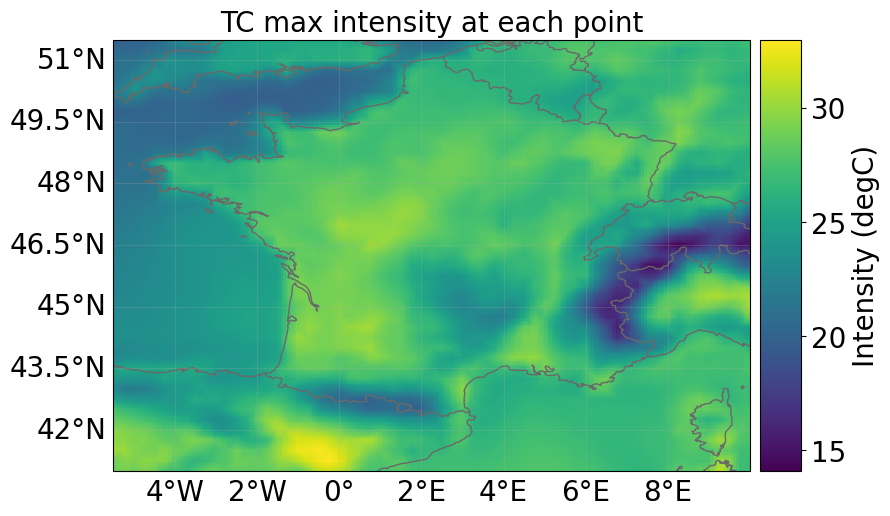

In [56]:
print(haz)
print("Events:", haz.intensity.shape[0])
print("Centroids:", haz.intensity.shape[1])

# Plot one day
haz.plot_intensity(event=0)

## Impact Function

In [58]:
import numpy as np
from climada.entity import ImpactFunc

temps = np.linspace(-10, 40, 100)

a = 0.5 / (18**2)
damage = a * (temps - 12)**2
damage = np.clip(damage, 0, 1)

impf = ImpactFunc()
impf.haz_type = 'TC' # adapt to your hazard
impf.id = 1
impf.name = 'Parabolic temp damage (center 12°C, 50% at 30°C)'

impf.intensity = temps
impf.mdd = damage
impf.paa = np.ones_like(temps)

impf.check()

<Axes: title={'center': 'TC 1: Parabolic temp damage (center 12°C, 50% at 30°C)'}, xlabel='Intensity ()', ylabel='Impact (%)'>

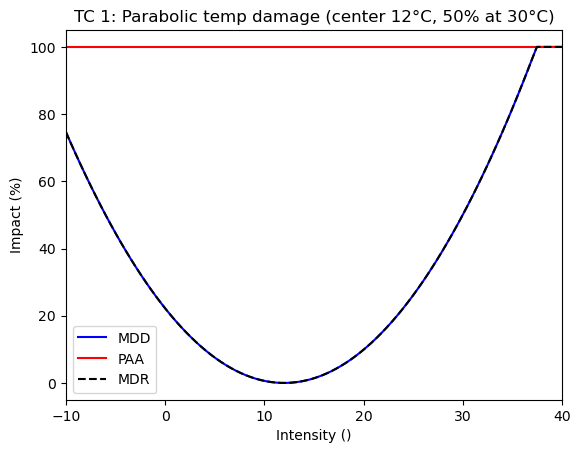

In [59]:
impf.plot()